# Part 3 — Model Baseline: LightGBM & XGBoost

**Train:** 2023–2024 (~16.4M rows)  
**Test:** 2025 (~4.2M rows)  
**Split strategy:** Chronological (no shuffled CV across years — prevents leakage)  

We train LightGBM as the primary new model (better histogram binning at 20M rows) and XGBoost as a cross-part baseline.

In [1]:
import sys
sys.path.insert(0, "../..")

import pandas as pd
import numpy as np
import lightgbm as lgb
import xgboost as xgb
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import config

config.assert_data_exists()

## 1. Load Processed Features

In [2]:
feat_path = config.DATA_PART3_PROCESSED / "flights_2023_2025_features.parquet"
df = pd.read_parquet(feat_path)
print(df.shape)
df.head()

(20588154, 19)


,MONTH,month_sin,month_cos,DAY_OF_WEEK,dow_sin,dow_cos,dep_hour,dep_minutes_since_midnight,is_peak_hour,is_red_eye,CRS_ELAPSED_TIME,DISTANCE,route_delay_rate,carrier_delay_rate,ORIGIN,DEST,OP_CARRIER,ARR_DEL15,YEAR
0,1,0.5,0.866025,1,0.781831,0.62349,14,840,False,False,146.0,765.0,0.215374,0.148695,BNA,JFK,9E,0,2023
1,1,0.5,0.866025,1,0.781831,0.62349,10,630,False,False,165.0,765.0,0.206889,0.148695,JFK,BNA,9E,0,2023
2,1,0.5,0.866025,1,0.781831,0.62349,18,1139,True,False,149.0,665.0,0.168045,0.148695,JFK,IND,9E,0,2023
3,1,0.5,0.866025,1,0.781831,0.62349,5,300,False,True,120.0,382.0,0.157074,0.148695,BGR,JFK,9E,0,2023
4,1,0.5,0.866025,1,0.781831,0.62349,12,735,False,False,122.0,589.0,0.123461,0.148695,ATL,XNA,9E,0,2023


## 2. Train / Test Split (Chronological)

In [3]:
TARGET = "ARR_DEL15"
CAT_COLS = ["ORIGIN", "DEST", "OP_CARRIER"]

FEATURES = [c for c in df.columns if c not in [TARGET, "year", "YEAR"]]

train = df[df["YEAR"] <= 2024]
test  = df[df["YEAR"] == 2025]

X_train, y_train = train[FEATURES], train[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train delay rate: {y_train.mean():.3f}  |  Test delay rate: {y_test.mean():.3f}")

Train: (13708670, 17)  |  Test: (6879484, 17)
Train delay rate: 0.207  |  Test delay rate: 0.223


## 3. Encode Categoricals

In [4]:
# LightGBM handles categoricals natively; encode to 'category' dtype
for col in CAT_COLS:
    if col in X_train.columns:
        X_train[col] = X_train[col].astype("category")
        X_test[col]  = X_test[col].astype("category")

## 4. LightGBM Baseline

In [5]:
lgb_params = {
    "objective": "binary",
    "metric": "auc",
    "n_estimators": 500,
    "learning_rate": 0.05,
    "num_leaves": 127,
    "min_child_samples": 100,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "n_jobs": -1,
    "verbose": -1,
    "random_state": 42,
}

lgb_model = lgb.LGBMClassifier(**lgb_params)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)],
)

Training until validation scores don't improve for 50 rounds


[100]	valid_0's auc: 0.656716


[200]	valid_0's auc: 0.657563


[300]	valid_0's auc: 0.658362


[400]	valid_0's auc: 0.65887


[500]	valid_0's auc: 0.659178
Did not meet early stopping. Best iteration is:
[499]	valid_0's auc: 0.659181


,boosting_type,'gbdt'
,num_leaves,127
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,100


In [6]:
lgb_prob = lgb_model.predict_proba(X_test)[:, 1]
lgb_pred = (lgb_prob >= 0.5).astype(int)

print("=== LightGBM ===")
print(f"Accuracy: {accuracy_score(y_test, lgb_pred):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, lgb_prob):.4f}")
print(f"F1:       {f1_score(y_test, lgb_pred):.4f}")
print(classification_report(y_test, lgb_pred))

=== LightGBM ===
Accuracy: 0.7773


ROC-AUC:  0.6592


F1:       0.0950


              precision    recall  f1-score   support

           0       0.78      0.99      0.87   5344846
           1       0.51      0.05      0.09   1534638

    accuracy                           0.78   6879484
   macro avg       0.65      0.52      0.48   6879484
weighted avg       0.72      0.78      0.70   6879484



## 5. XGBoost Baseline

In [7]:
# XGBoost doesn't handle category dtype — encode to integer codes
X_train_xgb = X_train.copy()
X_test_xgb  = X_test.copy()
for col in CAT_COLS:
    if col in X_train_xgb.columns:
        X_train_xgb[col] = X_train_xgb[col].cat.codes
        X_test_xgb[col]  = X_test_xgb[col].cat.codes

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="auc",
    early_stopping_rounds=30,
    tree_method="hist",  # fast for large datasets
    device="cuda",        # remove if no GPU
    n_jobs=-1,
    random_state=42,
    verbosity=1,
)
xgb_model.fit(X_train_xgb, y_train, eval_set=[(X_test_xgb, y_test)], verbose=100)

[0]	validation_0-auc:0.63734


[100]	validation_0-auc:0.64654


[200]	validation_0-auc:0.64776


[299]	validation_0-auc:0.64864


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",30
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [8]:
xgb_prob = xgb_model.predict_proba(X_test_xgb)[:, 1]
xgb_pred = (xgb_prob >= 0.5).astype(int)

print("=== XGBoost ===")
print(f"Accuracy: {accuracy_score(y_test, xgb_pred):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, xgb_prob):.4f}")
print(f"F1:       {f1_score(y_test, xgb_pred):.4f}")

/home/hareee234/miniconda3/envs/torch5070/lib/python3.12/site-packages/xgboost/core.py:751: UserWarning: [19:31:33] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


=== XGBoost ===
Accuracy: 0.7775


ROC-AUC:  0.6486


F1:       0.0655


## 6. Feature Importance (LightGBM)

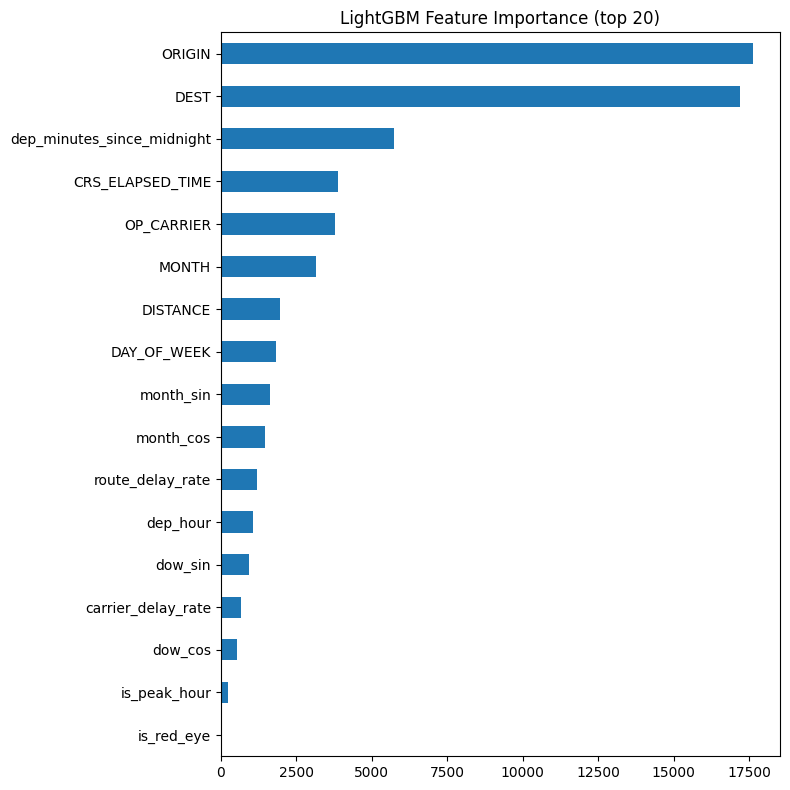

In [9]:
feat_imp = pd.Series(lgb_model.feature_importances_, index=FEATURES).sort_values(ascending=False)
feat_imp.head(20).plot(kind="barh", figsize=(8, 8), title="LightGBM Feature Importance (top 20)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Save Models

In [10]:
import joblib

out_dir = config.DATA_PART3_PROCESSED
lgb_model.booster_.save_model(str(out_dir / "lgb_baseline.txt"))
joblib.dump(xgb_model, out_dir / "xgb_baseline.joblib")
print("Models saved.")

Models saved.
